# Datathon 2026 - Task-Focused EDA

This notebook keeps only plots directly useful for forecasting daily `Revenue` in the test horizon.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')

if Path.cwd().name.lower() == 'notebooks':
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
FIG_DIR = PROJECT_ROOT / 'reports' / 'eda_task_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_DIR:', DATA_DIR)
print('FIG_DIR :', FIG_DIR)


DATA_DIR: E:\Temp\datathon_2026\data\raw
FIG_DIR : E:\Temp\datathon_2026\reports\eda_task_figures


In [2]:
sales = pd.read_csv(DATA_DIR / 'sales.csv', parse_dates=['Date'])
orders = pd.read_csv(DATA_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR / 'order_items.csv', low_memory=False)
web = pd.read_csv(DATA_DIR / 'web_traffic.csv', parse_dates=['date'])

sales = sales.sort_values('Date').copy()
print('sales shape:', sales.shape)
print('sales range:', sales['Date'].min().date(), '->', sales['Date'].max().date())


sales shape: (3833, 3)
sales range: 2012-07-04 -> 2022-12-31


## 1) Target Trend + Structural Change

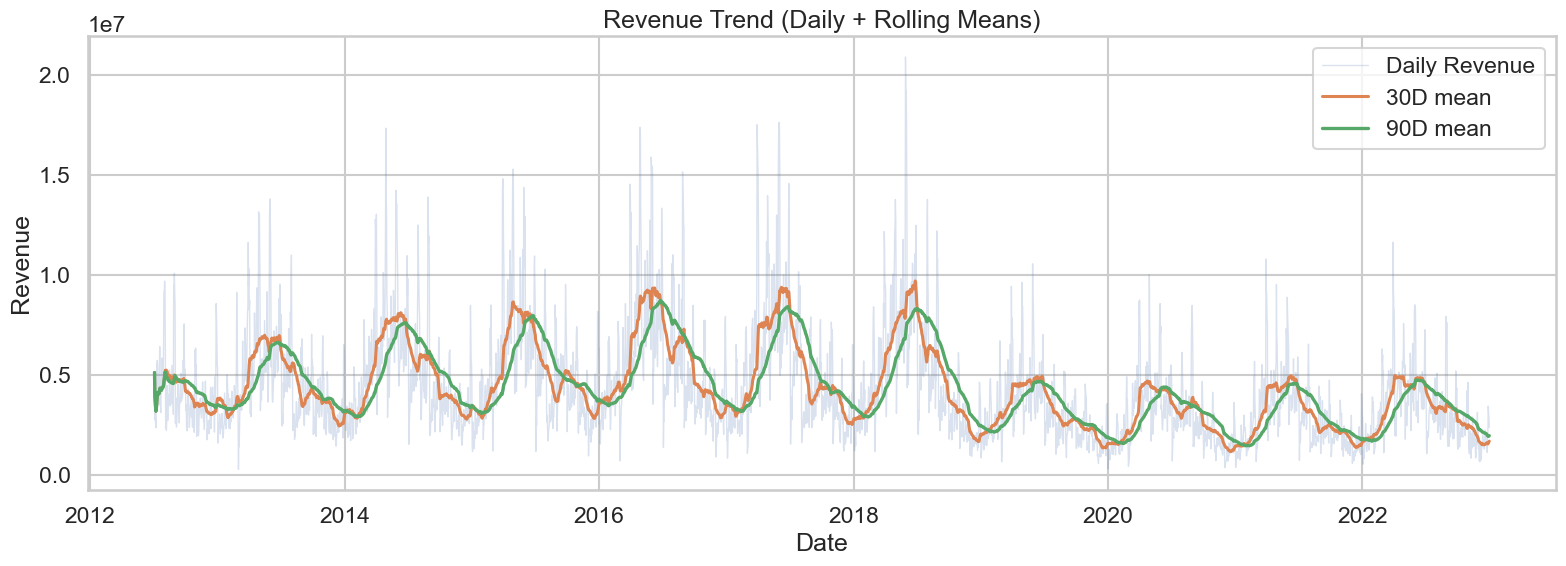

In [3]:
sales['rev_30d'] = sales['Revenue'].rolling(30, min_periods=1).mean()
sales['rev_90d'] = sales['Revenue'].rolling(90, min_periods=1).mean()

plt.figure(figsize=(16, 6))
plt.plot(sales['Date'], sales['Revenue'], alpha=0.2, linewidth=1, label='Daily Revenue')
plt.plot(sales['Date'], sales['rev_30d'], linewidth=2.2, label='30D mean')
plt.plot(sales['Date'], sales['rev_90d'], linewidth=2.4, label='90D mean')
plt.title('Revenue Trend (Daily + Rolling Means)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '01_revenue_trend_rolling.png', dpi=180)
plt.show()


## 2) Calendar Seasonality (Month + Weekday)

C:\Users\User\AppData\Local\Temp\ipykernel_19004\2062676567.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sales, x='weekday', y='Revenue', order=weekday_order, palette='Blues', ax=axes[1])


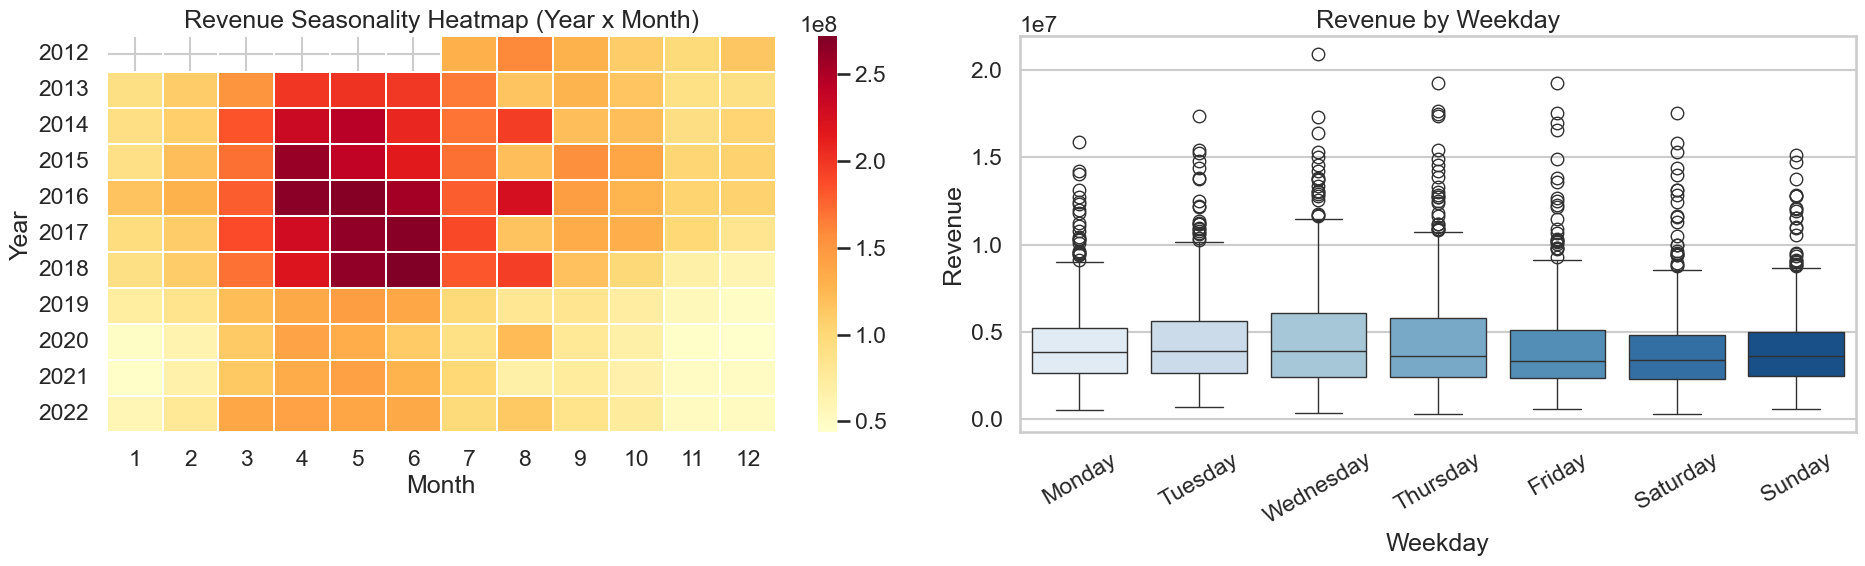

In [4]:
sales['year'] = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
sales['weekday'] = sales['Date'].dt.day_name()

heat = sales.pivot_table(index='year', columns='month', values='Revenue', aggfunc='sum')

fig, axes = plt.subplots(1, 2, figsize=(19, 6))
sns.heatmap(heat, cmap='YlOrRd', linewidths=0.3, linecolor='white', ax=axes[0])
axes[0].set_title('Revenue Seasonality Heatmap (Year x Month)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Year')

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.boxplot(data=sales, x='weekday', y='Revenue', order=weekday_order, palette='Blues', ax=axes[1])
axes[1].set_title('Revenue by Weekday')
axes[1].set_xlabel('Weekday')
axes[1].set_ylabel('Revenue')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_calendar_seasonality.png', dpi=180)
plt.show()


## 3) Autocorrelation Strength (Lag Dependence)

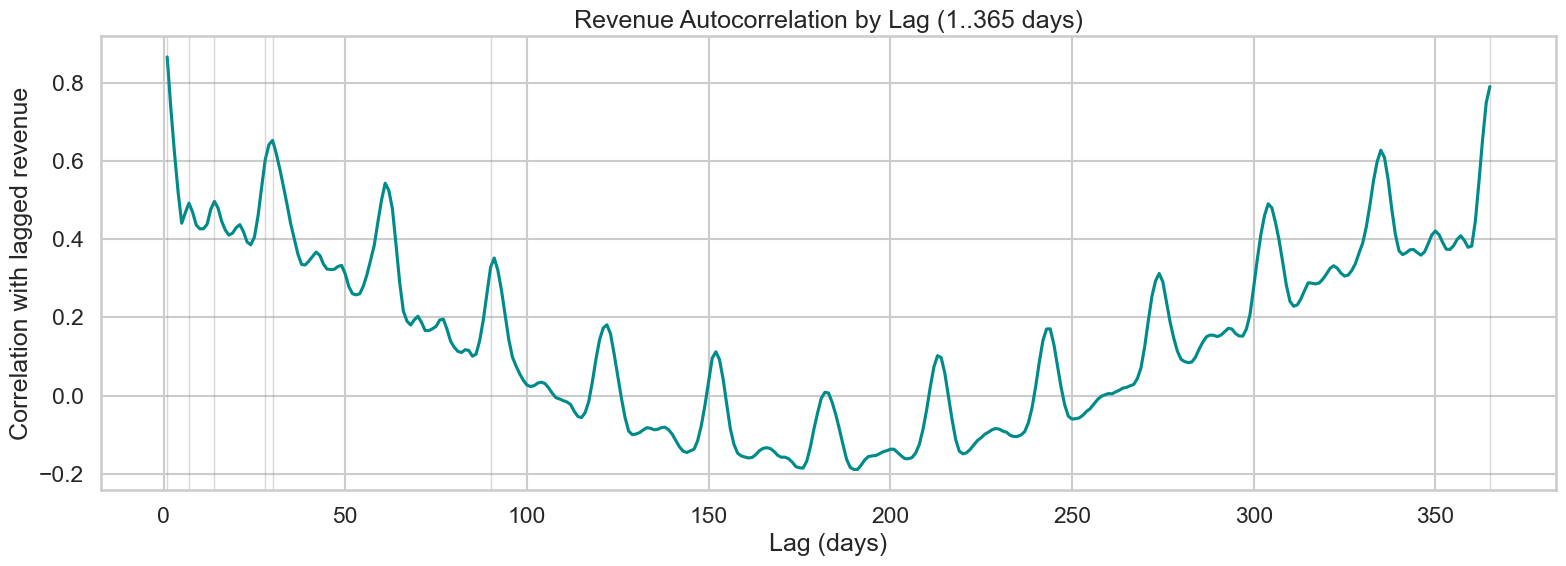

,lag,corr
0,1,0.865494
364,365,0.789784
363,364,0.748311
1,2,0.735113
362,363,0.654918
29,30,0.652300
28,29,0.641301
334,335,0.627014
2,3,0.621556
30,31,0.619435


In [5]:
max_lag = 365
lag_corr = []
for lag in range(1, max_lag + 1):
    c = sales['Revenue'].corr(sales['Revenue'].shift(lag))
    lag_corr.append((lag, c))
lag_df = pd.DataFrame(lag_corr, columns=['lag', 'corr']).dropna()

plt.figure(figsize=(16, 6))
plt.plot(lag_df['lag'], lag_df['corr'], color='darkcyan')
for v in [1, 7, 14, 28, 30, 90, 365]:
    plt.axvline(v, color='gray', alpha=0.3, linewidth=1)
plt.title('Revenue Autocorrelation by Lag (1..365 days)')
plt.xlabel('Lag (days)')
plt.ylabel('Correlation with lagged revenue')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_revenue_lag_autocorr.png', dpi=180)
plt.show()

lag_df.sort_values('corr', ascending=False).head(12)


## 4) Revenue vs COGS Stability

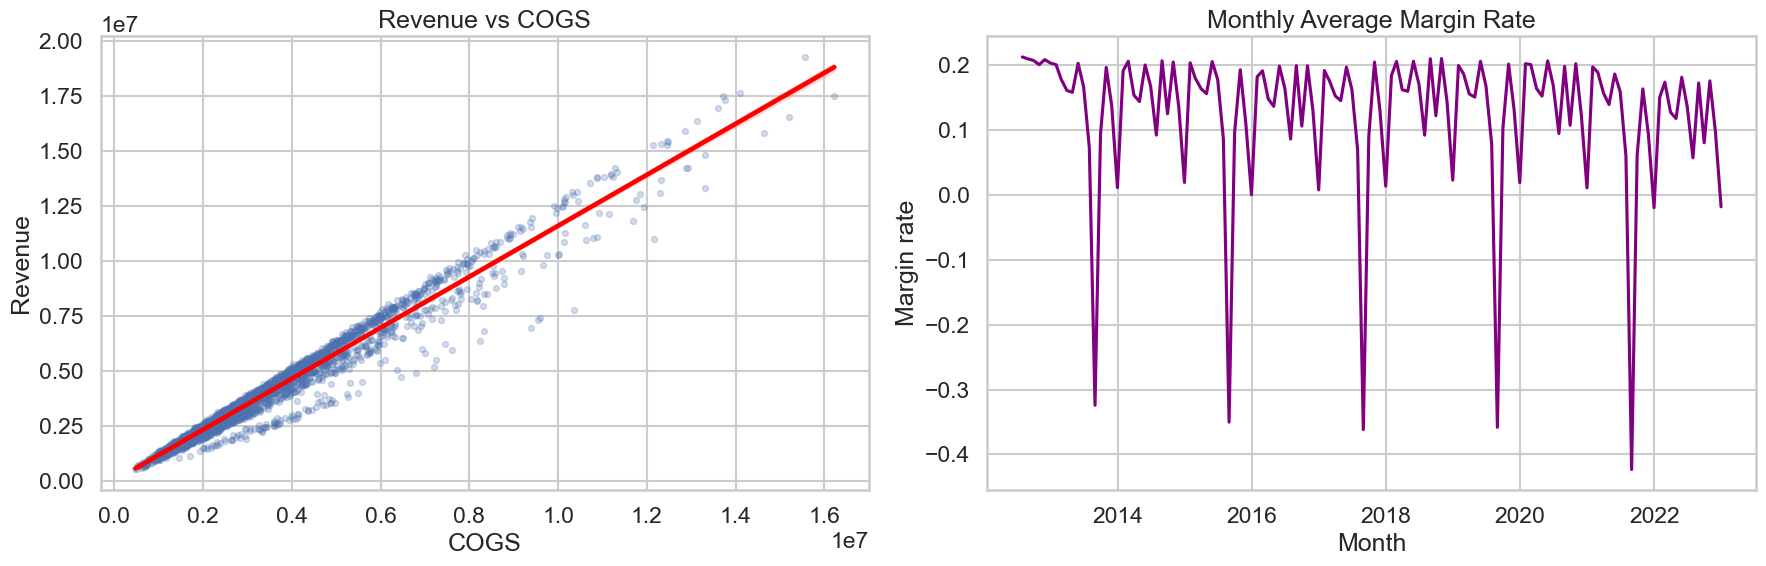

Revenue-COGS correlation: 0.976
Margin rate mean/std: 0.1254 0.1274


In [6]:
sales['margin_rate'] = (sales['Revenue'] - sales['COGS']) / sales['Revenue'].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.regplot(data=sales.sample(min(2500, len(sales)), random_state=42), x='COGS', y='Revenue',
            scatter_kws={'alpha':0.25, 's':18}, line_kws={'color':'red'}, ax=axes[0])
axes[0].set_title('Revenue vs COGS')

monthly_margin = sales.set_index('Date')['margin_rate'].resample('ME').mean().reset_index()
axes[1].plot(monthly_margin['Date'], monthly_margin['margin_rate'], color='purple')
axes[1].set_title('Monthly Average Margin Rate')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Margin rate')

plt.tight_layout()
plt.savefig(FIG_DIR / '04_revenue_cogs_relation.png', dpi=180)
plt.show()

print('Revenue-COGS correlation:', round(sales[['Revenue','COGS']].corr().loc['Revenue','COGS'], 4))
print('Margin rate mean/std:', round(sales['margin_rate'].mean(),4), round(sales['margin_rate'].std(),4))


## 5) Demand Driver Proxy (Orders and AOV)

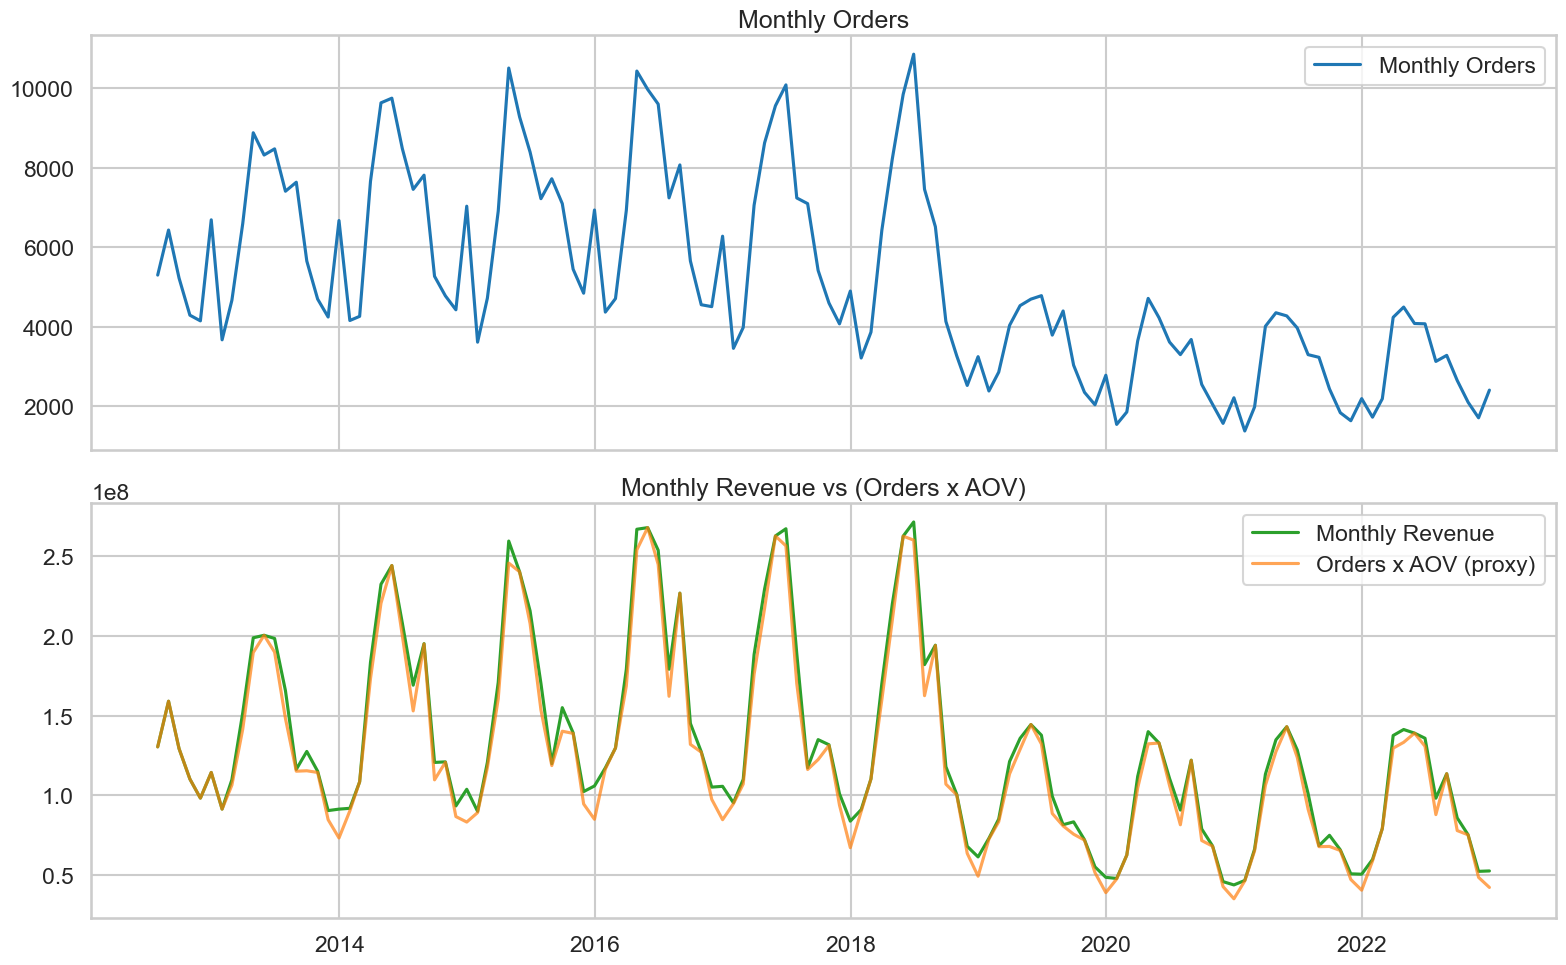

In [7]:
order_items['line_revenue'] = order_items['quantity'] * order_items['unit_price'] - order_items['discount_amount']
order_value = order_items.groupby('order_id', as_index=False).agg(order_revenue=('line_revenue','sum'))
orders2 = orders.merge(order_value, on='order_id', how='left')
orders2['order_revenue'] = orders2['order_revenue'].fillna(0)

orders_m = orders2.set_index('order_date').resample('ME').agg(
    orders=('order_id','nunique'),
    aov=('order_revenue','mean'),
).reset_index()

sales_m = sales.set_index('Date').resample('ME')['Revenue'].sum().reset_index()
orders_sales_m = orders_m.merge(sales_m, left_on='order_date', right_on='Date', how='inner')

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
axes[0].plot(orders_sales_m['order_date'], orders_sales_m['orders'], label='Monthly Orders', color='#1f77b4')
axes[0].set_title('Monthly Orders')
axes[0].legend()

axes[1].plot(orders_sales_m['order_date'], orders_sales_m['Revenue'], label='Monthly Revenue', color='#2ca02c')
axes[1].plot(orders_sales_m['order_date'], orders_sales_m['aov'] * orders_sales_m['orders'],
             label='Orders x AOV (proxy)', color='#ff7f0e', alpha=0.7)
axes[1].set_title('Monthly Revenue vs (Orders x AOV)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '05_orders_aov_proxy.png', dpi=180)
plt.show()


## 6) Web Signal vs Revenue (Historical only)

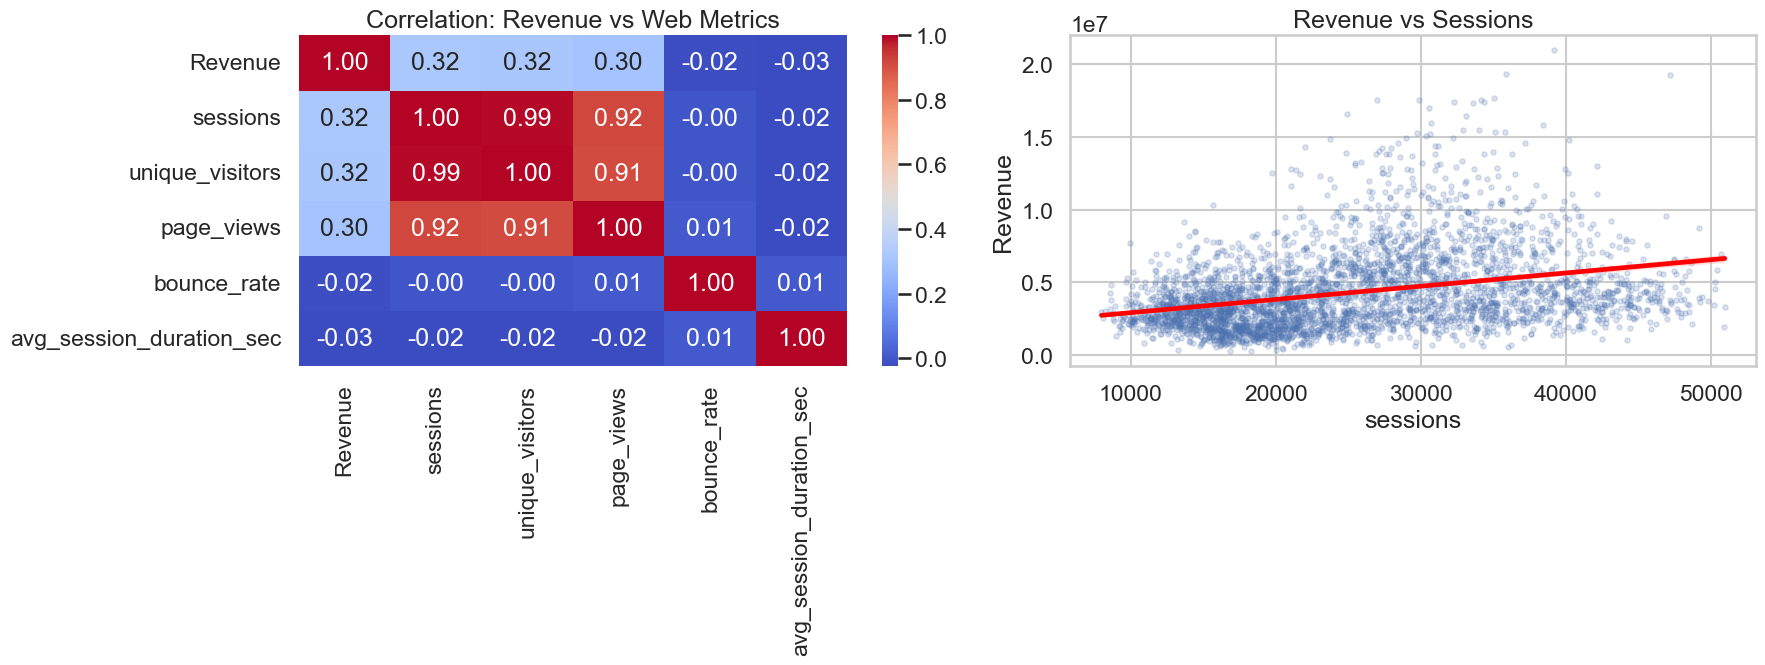

Revenue                     1.000000
sessions                    0.321050
unique_visitors             0.318787
page_views                  0.301573
bounce_rate                -0.020551
avg_session_duration_sec   -0.025622
Name: Revenue, dtype: float64


In [8]:
web_daily = web.rename(columns={'date':'Date'})[['Date','sessions','unique_visitors','page_views','bounce_rate','avg_session_duration_sec']]
sw = sales[['Date','Revenue']].merge(web_daily, on='Date', how='left')

corr = sw[['Revenue','sessions','unique_visitors','page_views','bounce_rate','avg_session_duration_sec']].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
axes[0].set_title('Correlation: Revenue vs Web Metrics')

sns.regplot(data=sw, x='sessions', y='Revenue', scatter_kws={'alpha':0.2, 's':14},
            line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Revenue vs Sessions')

plt.tight_layout()
plt.savefig(FIG_DIR / '06_web_revenue_relation.png', dpi=180)
plt.show()

print(corr['Revenue'].sort_values(ascending=False))


## 7) What can be used at inference time?

In [9]:
availability = pd.DataFrame({
    'feature_group': [
        'Calendar features (month/dow/week)',
        'Lag/rolling from past Revenue',
        'COGS (same-day true value)',
        'Future order/web/inventory true values',
    ],
    'available_for_2023_2024_prediction': [
        'Yes',
        'Yes',
        'No (unless separately forecasted)',
        'No (not directly provided in test)',
    ]
})
availability


,feature_group,available_for_2023_2024_prediction
0,Calendar features (month/dow/week),Yes
1,Lag/rolling from past Revenue,Yes
2,COGS (same-day true value),No (unless separately forecasted)
3,Future order/web/inventory true values,No (not directly provided in test)


### Practical takeaway
Use a pipeline that is robust with **date + lagged target features**. Treat exogenous sources mainly as insight/diagnostics unless you also forecast them.
